# Practice 3: Tool Calling Fundamentals

Agent에 있어서 **도구(Tool)**란, 외부 환경과 상호 작용할 수 있는 **Action**입니다.  
Agent의 손과 발을 잘 활용하기 위해서는 도구를 어떻게 정의할지가 매우 중요한 문제가 됩니다.


## Tool
- 도구는 에이전트가 **행동을 수행**하기 위해 호출하는 구성 요소
- **명확하게 정의된 입력과 출력**을 통해 세계와 상호작용할 수 있도록 하여 모델 역량을 확장
- 도구는 **호출 가능한 함수**와 그 **입력 스키마**를 캡슐화합니다.
- 이 값들은 호환 가능한 채팅 모델에 전달되어, 모델이 **도구를 호출할지 여부**와 **어떤 인수**로 사용할지 결정할 수 있습니다.
- 이러한 상황에서 툴 호출은 모델이 지정된 **입력 스키마에 부합하는 요청을 생성**할 수 있게 합니다.

## Tool Use Pattern (도구 사용)

지난 실습에서의 패턴을 떠올려봅니다.

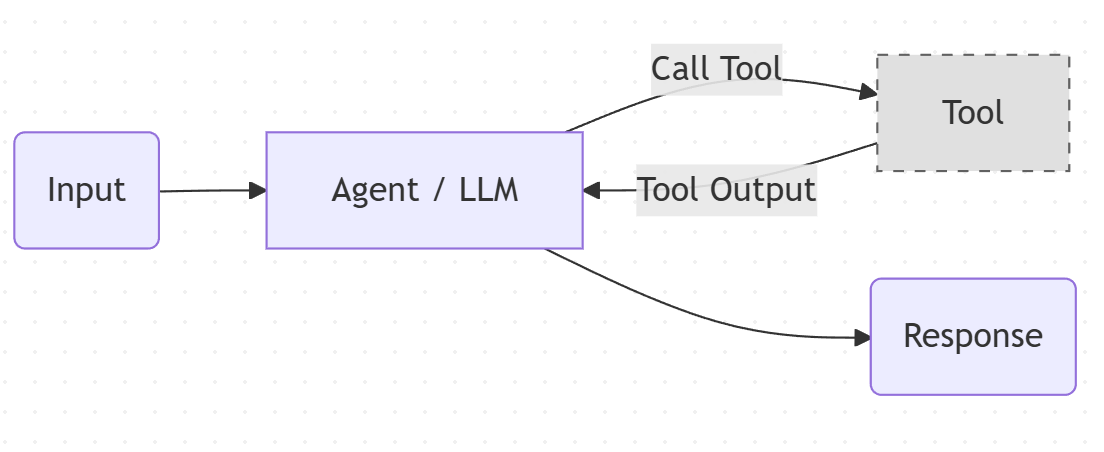

- **실시간 데이터**: 날씨, 주가, 뉴스 등
- **정확한 계산**: 수학 연산, 통계
- **외부 시스템 연동**: DB, API, 파일 시스템
- **행동 수행**: 이메일 발송, 예약, 결제

## 환경 설정

- 실습 환경 구축을 위한 패키지 설치 (설치 후 세션을 다시 시작해야합니다.)

In [ ]:
# !sudo apt-get update
# !sudo apt-get install -y graphviz libgraphviz-dev pkg-config python3-dev

In [ ]:
# !pip install langgraph langchain-upstage langchain==1.1.3 rich erdantic

- Google Colab의 '보안 비밀번호(Secrets)' 메뉴에 등록한 API KEY를 환경 변수로 불러옵니다.

In [ ]:
import os
from google.colab import userdata

# 설정할 키 목록
keys = [
    'LANGSMITH_API_KEY', 'UPSTAGE_API_KEY'
]

for key in keys:
    try:
        os.environ[key] = userdata.get(key)
    except:
        print(f"경고: {key}를 '보안 비밀번호'에서 찾을 수 없습니다.")

# 고정값 설정
os.environ["LANGSMITH_TRACING_V2"] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = 'agentic-workflow'

- 실습에 필요한 라이브러리 로드 및 LLM 모델 초기화

In [ ]:
from rich import print as rprint
from langchain.chat_models import init_chat_model

MODEL = "solar-pro2"
llm = init_chat_model(
    model=MODEL,
    temperature=0.1
)

---
## Part1: 수동 Tool Calling

### 1.1 Tool Schema 구조

```json
{
  "type": "function",
  "function": {
    "name": "함수명",
    "description": "함수 설명 (LLM이 도구 선택 시 참고)",
    "parameters": {
      "type": "object",
      "properties": {
        "param1": {
          "type": "string",
          "description": "파라미터 설명"
        }
      },
      "required": ["param1"]
    }
  }
}
```

### 핵심 포인트
- **name**: 명확하고 동작을 나타내는 이름 (get_, calculate_, search_ 등)
- **description**: LLM이 언제 이 도구를 사용할지 결정하는 핵심 정보
- **parameters**: JSON Schema 형식으로 파라미터 정의

In [ ]:
import json

# 1. Tool 함수 구현
def calculator(operation: str, a: float, b: float) -> str:
    """기본 사칙연산 계산기"""
    operations = {
        "add": a + b,
        "subtract": a - b,
        "multiply": a * b,
        "divide": a / b if b != 0 else "Error: Division by zero"
    }
    result = operations.get(operation, "Unknown operation")
    return f"{a} {operation} {b} = {result}"

# 2. Tool Schema 정의
calculator_tool = {
    "type": "function",
    "function": {
        "name": "calculator",
        "description": "Perform basic arithmetic operations: add, subtract, multiply, divide",
        "parameters": {
            "type": "object",
            "properties": {
                "operation": {
                    "type": "string",
                    "enum": ["add", "subtract", "multiply", "divide"],
                    "description": "The arithmetic operation to perform"
                },
                "a": {
                    "type": "number",
                    "description": "First operand"
                },
                "b": {
                    "type": "number",
                    "description": "Second operand"
                }
            },
            "required": ["operation", "a", "b"]
        }
    }
}

print("Calculator Tool Schema:")
rprint(json.dumps(calculator_tool, indent=2))

Calculator Tool Schema:


{
  "type": "function",
  "function": {
    "name": "calculator",
    "description": "Perform basic arithmetic operations: add, subtract, multiply, divide",
    "parameters": {
      "type": "object",
      "properties": {
        "operation": {
          "type": "string",
          "enum": [
            "add",
            "subtract",
            "multiply",
            "divide"
          ],
          "description": "The arithmetic operation to perform"
        },
        "a": {
          "type": "number",
          "description": "First operand"
        },
        "b": {
          "type": "number",
          "description": "Second operand"
        }
      },
      "required": [
        "operation",
        "a",
        "b"
      ]
    }
  }
}

---
### 1.2 Tool Calling 실행 흐름

In [ ]:
import json
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

def run_with_tool(user_message: str, tools: list, functions: dict) -> str:
    """
    Tool Calling 흐름
    """
    # 1. 메시지 초기화
    messages = [HumanMessage(content=user_message)]
    print(f"[1] 사용자: {user_message}")

    # 2. LLM 호출 (tools를 바인딩하여 호출)
    # llm 객체는 이미 정의되어 있고, bind_tools가 지원된다고 가정합니다.
    llm_with_tools = llm.bind_tools(tools)
    response = llm_with_tools.invoke(messages)

    # 3. Tool 호출 여부 확인
    if not response.tool_calls:
        print("[2] Tool 호출 없음 - 직접 응답")
        return response

    # 4. Tool 호출 처리
    print(f"[2] Tool 호출 감지: {len(response.tool_calls)}개")
    messages.append(response) # AI의 Tool Call 메시지 추가

    for tool_call in response.tool_calls:
        func_name = tool_call["name"]
        func_args = tool_call["args"] # LangChain은 이미 dict로 파싱해둡니다.

        print(f"[3] Tool 실행: {func_name}({func_args})")

        if func_name in functions:
            result = functions[func_name](**func_args)
        else:
            result = f"Error: Unknown function {func_name}"

        print(f"[4] Tool 결과: {result}")

        # 5. Tool 실행 결과를 ToolMessage로 추가
        messages.append(ToolMessage(
            tool_call_id=tool_call["id"],
            content=str(result)
        ))

    # 6. 최종 응답 생성
    final_response = llm_with_tools.invoke(messages)
    print(f"[5] 최종 응답 생성")

    return final_response

In [ ]:
# 테스트
tools = [calculator_tool]
functions = {"calculator": calculator}

queries = [
    "123 곱하기 456은?",
    "1000을 7로 나누면?",
    "안녕하세요?"
]

for q in queries:
    print("\n" + "="*50)
    result = run_with_tool(q, tools, functions)
    print(f"\n최종 응답: {result.content}")


[1] 사용자: 123 곱하기 456은?
[2] Tool 호출 감지: 1개
[3] Tool 실행: calculator({'operation': 'multiply', 'a': 123, 'b': 456})
[4] Tool 결과: 123 multiply 456 = 56088
[5] 최종 응답 생성

최종 응답: 123 곱하기 456의 결과는 **56,088**입니다. 계산 과정은 다음과 같습니다:

- 123 × 400 = 49,200  
- 123 × 50 = 6,150  
- 123 × 6 = 738  
- 총합: 49,200 + 6,150 + 738 = **56,088**  

따라서 정답은 **56,088**입니다.

[1] 사용자: 1000을 7로 나누면?
[2] Tool 호출 감지: 1개
[3] Tool 실행: calculator({'a': 1000, 'b': 7, 'operation': 'divide'})
[4] Tool 결과: 1000 divide 7 = 142.85714285714286
[5] 최종 응답 생성

최종 응답: 1000을 7로 나눈 결과는 **142.85714285714286**입니다.  

(정확한 분수 표현: \( \frac{1000}{7} \))

[1] 사용자: 안녕하세요?
[2] Tool 호출 없음 - 직접 응답

최종 응답: 안녕하세요! 어떻게 도와드릴까요? 😊  

질문을 주신다면, 필요한 경우 계산기 함수를 사용해 정확한 답변을 드리겠습니다.  
(예: "123 + 456 계산해주세요" → `calculator` 호출)  

간단한 대화나 일반 지식 질문은 바로 답변해 드립니다!


### 1.3 다중 Tool Call 실행 흐름

In [ ]:
# 추가 Tool 정의

# Tool 2: 날씨 조회
def get_weather(city: str, unit: str = "celsius") -> str:
    """날씨 조회 (Mock)"""
    weather_data = {
        "서울": {"temp": 22, "condition": "맑음"},
        "부산": {"temp": 25, "condition": "구름 조금"},
        "제주": {"temp": 27, "condition": "맑음"},
    }

    data = weather_data.get(city, {"temp": 20, "condition": "정보 없음"})
    temp = data["temp"]
    if unit == "fahrenheit":
        temp = temp * 9/5 + 32

    return f"{city}: {temp}°{'F' if unit == 'fahrenheit' else 'C'}, {data['condition']}"

weather_tool = {
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Get current weather for a Korean city (서울, 부산, 제주 등)",
        "parameters": {
            "type": "object",
            "properties": {
                "city": {
                    "type": "string",
                    "description": "City name in Korean"
                },
                "unit": {
                    "type": "string",
                    "enum": ["celsius", "fahrenheit"],
                    "description": "Temperature unit (default: celsius)"
                }
            },
            "required": ["city"]
        }
    }
}

from datetime import datetime
# Tool 3: 현재 시간
def get_current_time(timezone: str = "KST") -> str:
    """현재 시간 조회"""
    return f"현재 시간 ({timezone}): {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"

time_tool = {
    "type": "function",
    "function": {
        "name": "get_current_time",
        "description": "Get the current date and time",
        "parameters": {
            "type": "object",
            "properties": {
                "timezone": {
                    "type": "string",
                    "description": "Timezone (default: KST)"
                }
            }
        }
    }
}

# Tool 4: 웹 검색 (Mock)
def search_web(query: str) -> str:
    """웹 검색 (Mock)"""
    return f"'{query}' 검색 결과: 관련 정보 3건을 찾았습니다."

search_tool = {
    "type": "function",
    "function": {
        "name": "search_web",
        "description": "Search the web for current information and news",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "description": "Search query"
                }
            },
            "required": ["query"]
        }
    }
}

print("4개 Tool 정의 완료!")

4개 Tool 정의 완료!


In [ ]:
# 다중 Tool 테스트
all_tools = [calculator_tool, weather_tool, time_tool, search_tool]
all_functions = {
    "calculator": calculator,
    "get_weather": get_weather,
    "get_current_time": get_current_time,
    "search_web": search_web
}

test_queries = [
    "서울 날씨 어때?",
    "지금 몇 시야?",
    "500 나누기 7은?",
    "AI 에이전트 최신 뉴스 검색해줘"
]

for q in test_queries:
    print("\n" + "="*50)
    result = run_with_tool(q, all_tools, all_functions)
    print(f"\n응답: {result}")


[1] 사용자: 서울 날씨 어때?
[2] Tool 호출 감지: 1개
[3] Tool 실행: get_weather({'city': '서울'})
[4] Tool 결과: 서울: 22°C, 맑음
[5] 최종 응답 생성

응답: content='서울의 현재 날씨는 22°C로 맑고 청명합니다. ☀️  \n\n간단히 요약하면:  \n- **기온**: 22°C  \n- **날씨 상태**: 맑음  \n\n추가 정보가 필요하시면 언제든지 요청해 주세요!' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 881, 'total_tokens': 931, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'solar-pro2-251215', 'system_fingerprint': None, 'id': 'e033fc5c-c856-426f-af07-79192b135191', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019b7c56-d148-76e3-a2d3-6236c0f0e035-0' usage_metadata={'input_tokens': 881, 'output_tokens': 50, 'total_tokens': 931, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reas

In [ ]:
# 도구를 2개 이상 쓸만한 쿼리를 작성해보자
parallel_query = "서울과 부산의 날씨를 비교해줘"

print(f"질문: {parallel_query}")
print("="*50)

llm_with_tools = llm.bind_tools(all_tools)
response = llm_with_tools.invoke([HumanMessage(content=parallel_query)])

if response.tool_calls:
    print(f"\n병렬 Tool 호출: {len(response.tool_calls)}개")
    for i, tc in enumerate(response.tool_calls, 1):
        print(f"  {i}. {tc['name']}({tc['args']})")
else:
    print("\nTool 호출 없음")
    print(f"응답: {response.content}")

질문: 서울과 부산의 날씨를 비교해줘

병렬 Tool 호출: 2개
  1. get_weather({'city': '서울'})
  2. get_weather({'city': '부산'})


In [ ]:
# 병렬 호출 전체 처리
result = run_with_tool(parallel_query, all_tools, all_functions)
print(f"\n최종 응답: {result}")

[1] 사용자: 서울과 부산의 날씨를 비교해줘
[2] Tool 호출 감지: 2개
[3] Tool 실행: get_weather({'city': '서울'})
[4] Tool 결과: 서울: 22°C, 맑음
[3] Tool 실행: get_weather({'city': '부산'})
[4] Tool 결과: 부산: 25°C, 구름 조금
[5] 최종 응답 생성

최종 응답: content='서울과 부산의 현재 날씨를 비교해 드리겠습니다.  \n\n- **서울**: 22°C, 맑음  \n- **부산**: 25°C, 구름 조금  \n\n부산이 서울보다 3°C 더 높으며, 두 지역 모두 맑은 날씨를 보이고 있습니다. 부산은 약간의 구름이 있지만 대체로 청명한 상태입니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 920, 'total_tokens': 984, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'solar-pro2-251215', 'system_fingerprint': None, 'id': '7ceb5c4f-d6be-4e10-a565-1a14d8b9d627', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019b7c56-f9ab-7222-842e-4f4b39cca864-0' usage_metadata={'input_tokens': 920, 'output_tokens':

---
## Part2: LangChain Tool Decoration

https://docs.langchain.com/oss/python/langchain/tools

**간단한 도구 정의**
- 함수의 Docstring이 Tool Description으로 들어갑니다.
- 타입 힌트는 도구의 입력 스키마를 정의합니다.

| 구성 요소 | 설명 |
|----------|------|
| **name** | Tool 이름 (기본: 함수명) |
| **description** | Tool 설명 (기본: docstring) - LLM이 언제 사용할지 결정 |
| **args_schema** | 입력 파라미터 스키마 (타입 힌트에서 자동 생성) |
| **func** | 실제 실행할 함수 |

```python
from langchain_core.tools import tool

@tool
def my_function(param: str) -> str:
    """이 설명이 description이 됩니다."""
    return result
```

### 2.1 @Tool 사용법

In [ ]:
"""@tool 데코레이터 기본 사용법"""

from langchain_core.tools import tool

# 1. 기본 사용법 - 함수명이 Tool 이름, docstring이 설명이 됨
@tool
def search_database(query: str, limit: int = 10) -> str:
    """Search the customer database for records matching the query.

    Args:
        query: Search terms to look for
        limit: Maximum number of results to return
    """
    return f"'{query}' 검색 결과: {limit}개 발견"

rprint(search_database)

StructuredTool(
    name='search_database',
    description='Search the customer database for records matching the query.\n\n    Args:\n        query: Search 
terms to look for\n        limit: Maximum number of results to return',
    args_schema=<class 'langchain_core.utils.pydantic.search_database'>,
    func=<function search_database at 0x7b0362753420>
)

### 2.2 Customizing Tool

In [ ]:
"""사용자 지정 이름"""

@tool("web_search")  # Custom name - 오버라이드
def search(query: str) -> str:
    """Search the web for information."""
    return f"Results for: {query}"

rprint(search)  # web_search

StructuredTool(
    name='web_search',
    description='Search the web for information.',
    args_schema=<class 'langchain_core.utils.pydantic.web_search'>,
    func=<function search at 0x7b03625dfb00>
)

In [ ]:
"""사용자 지정 도구 설명"""

# Custom description - 오버라이드
@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

rprint(calc) # Performs arithmetic calculations. Use this for any math problems.

StructuredTool(
    name='calculator',
    description='Performs arithmetic calculations. Use this for any math problems.',
    args_schema=<class 'langchain_core.utils.pydantic.calculator'>,
    func=<function calc at 0x7b036261c4a0>
)

### 2.3 Tool Description (Non Pydantic v.s. Pydantic)


In [ ]:
"""Json 스키마를 활용한 도구 정의"""
weather_schema = {
    "type": "object",
    "properties": {
        "location": {"type": "string"},
        "units": {"type": "string"},
        "include_forecast": {"type": "boolean"}
    },
    "required": ["location", "units", "include_forecast"]
}

@tool(args_schema=weather_schema)
def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
    """Get current weather and optional forecast."""
    temp = 22 if units == "celsius" else 72
    result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
    if include_forecast:
        result += "\nNext 5 days: Sunny"
    return result

rprint(get_weather)

StructuredTool(
    name='get_weather',
    description='Get current weather and optional forecast.',
    args_schema={
        'type': 'object',
        'properties': {
            'location': {'type': 'string'},
            'units': {'type': 'string'},
            'include_forecast': {'type': 'boolean'}
        },
        'required': ['location', 'units', 'include_forecast']
    },
    func=<function get_weather at 0x7b036261c680>
)

In [ ]:
"""Pydantic을 활용한 도구 정의"""
from pydantic import BaseModel, Field
from typing import Literal

class WeatherInput(BaseModel):
    """Input for weather queries."""
    location: str = Field(description="City name or coordinates")
    units: Literal["celsius", "fahrenheit"] = Field(
        default="celsius",
        description="Temperature unit preference"
    )
    include_forecast: bool = Field(
        default=False,
        description="Include 5-day forecast"
    )

@tool(args_schema=WeatherInput)
def get_weather(location: str, units: str = "celsius", include_forecast: bool = False) -> str:
    """Get current weather and optional forecast."""
    temp = 22 if units == "celsius" else 72
    result = f"Current weather in {location}: {temp} degrees {units[0].upper()}"
    if include_forecast:
        result += "\nNext 5 days: Sunny"
    return result

rprint(get_weather)

StructuredTool(
    name='get_weather',
    description='Get current weather and optional forecast.',
    args_schema=<class '__main__.WeatherInput'>,
    func=<function get_weather at 0x7b036261c540>
)

In [ ]:
# json 스키마로 변환  (LLM이 이해하는 언어(JSON Schema)로 자동 변환)
get_weather.args_schema.model_json_schema()

{'description': 'Input for weather queries.',
 'properties': {'location': {'description': 'City name or coordinates',
   'title': 'Location',
   'type': 'string'},
  'units': {'default': 'celsius',
   'description': 'Temperature unit preference',
   'enum': ['celsius', 'fahrenheit'],
   'title': 'Units',
   'type': 'string'},
  'include_forecast': {'default': False,
   'description': 'Include 5-day forecast',
   'title': 'Include Forecast',
   'type': 'boolean'}},
 'required': ['location'],
 'title': 'WeatherInput',
 'type': 'object'}

차이가 보이시나요?

---
## Part 3: Pydantic BaseModel을 활용한 Tool 정의 가이드

Pydantic BaseModel의 강력한 기능들을 알아보고,
Tool 정의에 대한 직관을 얻습니다.

### 3.1 자동 Json Schema 생성

- 코드가 곧 프롬프트가 됩니다.
- `model_json_schema()`를 통해 API가 무엇을 보는지 정확히 확인할 수 있습니다.
- DocString, Attributes, Types, Filed Description 등이 스키마의 일부가 된걸 확인하세요.

```python
get_weather.args_schema.model_json_schema()
```

```text
>> {'description': 'Input for weather queries.',
 'properties': {'location': {'description': 'City name or coordinates',
   'title': 'Location',
   'type': 'string'},
  'units': {'default': 'celsius',
   'description': 'Temperature unit preference',
   'enum': ['celsius', 'fahrenheit'],
   'title': 'Units',
   'type': 'string'},
  'include_forecast': {'default': False,
   'description': 'Include 5-day forecast',
   'title': 'Include Forecast',
   'type': 'boolean'}},
 'required': ['location'],
 'title': 'WeatherInput',
 'type': 'object'}
```

### 3.2 가독성과 유지 보수성

- 역직렬화(사람이 보기에 편한 포맷) 된 프롬프트를 분리하는 대신 코드로 간편하게 관리할 수 있다는걸 생각해보세요.
- 아래 예시 스키마는, 임의로 작성한 복잡한 형태의 예시 입니다. 중첩 구조로 이루어져 있습니다.
- erdantic 라이브러리를 통해 ERD를 그려고 형태를 파악할 수 있습니다. (BaseModel에 적용 가능)

**예시 스키마 - 리서치 계획 수립 도구 스키마**
- ResearchPlan: 프로젝트 제목, 리서치 단계 목록
- ResearchStep: 작업 명칭("경쟁사 가격 조사"), 상세 목표 , 리서치 방법론(실시간, 학술 논문, 산업동향 등)

**작성 원칙**
- 명확한 설명
- 선택지 활용(Literal)
- 값 범위 제한(ge, le)
- 구체적 예시 포함
- default 값 활용

In [ ]:
from enum import Enum
from typing import List, Literal, Optional
from pydantic import BaseModel, Field

class ResearchStep(BaseModel):
    """Represents a single granular step within a comprehensive research plan."""

    # 명확하게, 상세 예시
    task_name: str = Field(
        description="A concise title for the task (e.g., 'Competitor Pricing Analysis')"
    )

    # 명확하게, 상세 예시
    detailed_objective: str = Field(
        description="A comprehensive description of what must be achieved in this step. "
                    "Be specific: instead of 'Research A', use 'Collect pricing data for "
                    "Product X from Company B and format it into a comparison table.'"
    )

    # 명확하게, 상세 예시, Literal 사용(선택지 강제)
    method: Literal["WEB_SCRAPING", "PAPER_REVIEW", "MARKET_ANALYSIS"] = Field(
        description=(
            "The specific technique to be used for this research step. "
            "Choose 'WEB_SCRAPING' to extract data from public websites (e.g., e-commerce pricing), "
            "'PAPER_REVIEW' to analyze academic/scholarly publications (e.g., medical studies), "
            "or 'MARKET_ANALYSIS' to evaluate industry trends and competitor data (e.g., market share)."
        )
    )

    # 명확하게, 상세 예시, 범위 제한
    priority: int = Field(
        default=3, # Appropriate Default
        ge=1,      # Range Limit (Min)
        le=5,      # Range Limit (Max)
        description="The urgency of the task on a scale from 1 (Lowest) to 5 (Highest)."
    )

class ResearchPlan(BaseModel):
    """A structured schema for generating a multi-step research execution plan."""

    project_title: str = Field(description="The overarching title of the research project.")

    steps: List[ResearchStep] = Field(
        description="A sequence of logically segmented research tasks required to complete the project."
    )

@tool(args_schema=ResearchPlan)
def create_research_plan(project_title: str, steps: List[ResearchStep]) -> str:
    """
    Creates a structured, multi-step research execution plan.
    Use this tool when a complex inquiry needs to be broken down into actionable segments.
    """
    # 실제 도구 실행 로직 (예: DB 저장 또는 다음 에이전트에게 전달)
    return f"Project '{project_title}' initialized with {len(steps)} tasks."

In [ ]:
rprint(create_research_plan.args_schema.model_json_schema())

{
    '$defs': {
        'ResearchStep': {
            'description': 'Represents a single granular step within a comprehensive research plan.',
            'properties': {
                'task_name': {
                    'description': "A concise title for the task (e.g., 'Competitor Pricing Analysis')",
                    'title': 'Task Name',
                    'type': 'string'
                },
                'detailed_objective': {
                    'description': "A comprehensive description of what must be achieved in this step. Be specific:
instead of 'Research A', use 'Collect pricing data for Product X from Company B and format it into a comparison 
table.'",
                    'title': 'Detailed Objective',
                    'type': 'string'
                },
                'method': {
                    'description': "The specific technique to be used for this research step. Choose 'WEB_SCRAPING'
to extract data from public websites (e.g., e-commerce pricing), 'PAPER_REVIEW' to analyze academic/scholarly 
publications (e.g., medical studies), or 'MARKET_ANALYSIS' to evaluate industry trends and competitor data (e.g., 
market share).",
                    'enum': ['WEB_SCRAPING', 'PAPER_REVIEW', 'MARKET_ANALYSIS'],
                    'title': 'Method',
                    'type': 'string'
                },
                'priority': {
                    'default': 3,
                    'description': 'The urgency of the task on a scale from 1 (Lowest) to 5 (Highest).',
                    'maximum': 5,
                    'minimum': 1,
                    'title': 'Priority',
                    'type': 'integer'
                }
            },
            'required': ['task_name', 'detailed_objective', 'method'],
            'title': 'ResearchStep',
            'type': 'object'
        }
    },
    'description': 'A structured schema for generating a multi-step research execution plan.',
    'properties': {
        'project_title': {
            'description': 'The overarching title of the research project.',
            'title': 'Project Title',
            'type': 'string'
        },
        'steps': {
            'description': 'A sequence of logically segmented research tasks required to complete the project.',
            'items': {'$ref': '#/$defs/ResearchStep'},
            'title': 'Steps',
            'type': 'array'
        }
    },
    'required': ['project_title', 'steps'],
    'title': 'ResearchPlan',
    'type': 'object'
}

EntityRelationshipDiagram(
    models={'__main__.ResearchPlan': ModelInfo(...), '__main__.ResearchStep': ModelInfo(...)},
    edges={'__main__.ResearchPlan-steps-__main__.ResearchStep': Edge(...)}
)

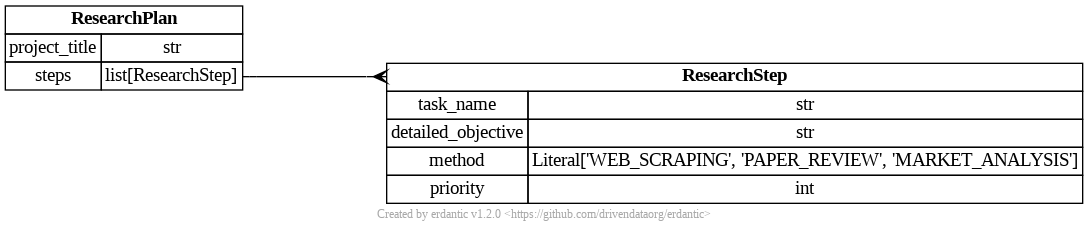

In [ ]:
import erdantic as erd
from erdantic.examples.pydantic import Party

erd.create(ResearchPlan)

### 3.3 강력한 타입 검증
- int, float, datetime 등의 타입 체크는 물론, 위에서 다룬 ge(크거나 같음), le(작거나 같음), pattern(정규식) 등을 통해 데이터의 무결성을 실행 전 단계에서 보장할 수 있습니다.
- 기본 제약 조건 외에도 비즈니스 조건에 맞는 자체 Validator를 @field_validator를 통해 구현할 수 있습니다.

#### 기본 Validation 에러

Literal 값에 없는 방식이나, ge/le 범위를 벗어난 데이터를 넣었을 때 발생하는 에러

In [ ]:
from pydantic import ValidationError
print("=== [Case 1] 기본적인 Pydantic 검증 에러 테스트 ===")

invalid_data = {
    "project_title": "AI Trend Research",
    "steps": [
        {
            "task_name": "Too High Priority",
            "detailed_objective": "Test range error",
            "method": "INTERNET_SEARCH", # ❌ Literal에 없는 값 (에러 1)
            "priority": 10              # ❌ 1~5 범위를 벗어남 (에러 2)
        }
    ]
}

try:
    create_research_plan.invoke(invalid_data)
except ValidationError as e:
    print("❌ 데이터 검증 실패!")
    rprint(e)

=== [Case 1] 기본적인 Pydantic 검증 에러 테스트 ===
❌ 데이터 검증 실패!


2 validation errors for ResearchPlan
steps.0.method
  Input should be 'WEB_SCRAPING', 'PAPER_REVIEW' or 'MARKET_ANALYSIS' [type=literal_error, 
input_value='INTERNET_SEARCH', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/literal_error
steps.0.priority
  Input should be less than or equal to 5 [type=less_than_equal, input_value=10, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal

#### 커스텀 검증
- task_name이 5글자 보다 적은지 검증
```python
    @field_validator('task_name')
    @classmethod
    def validate_task_name(cls, v: str) -> str:
        if len(v) < 5:
            raise ValueError("Task name is too short! Must be at least 5 characters.")
        return v
```
- 'research', 'analyze'라는 키워드가 detailed_objective에서 누락되었는지 검증
```python
    @field_validator('detailed_objective')
    @classmethod
    def check_objective_quality(cls, v: str) -> str:
        if "research" not in v.lower() and "analyze" not in v.lower():
            raise ValueError("Objective must include keywords like 'research' or 'analyze' for clarity.")
        return v
```

In [ ]:
from pydantic import field_validator

class ResearchStep(BaseModel):
    """Represents a single granular step within a comprehensive research plan."""

    # 명확하게, 상세 예시
    task_name: str = Field(
        description="A concise title for the task (e.g., 'Competitor Pricing Analysis')"
    )

    # 명확하게, 상세 예시
    detailed_objective: str = Field(
        description="A comprehensive description of what must be achieved in this step. "
                    "Be specific: instead of 'Research A', use 'Collect pricing data for "
                    "Product X from Company B and format it into a comparison table.'"
    )

    # 명확하게, 상세 예시, Literal 사용(선택지 강제)
    method: Literal["WEB_SCRAPING", "PAPER_REVIEW", "MARKET_ANALYSIS"] = Field(
        description=(
            "The specific technique to be used for this research step. "
            "Choose 'WEB_SCRAPING' to extract data from public websites (e.g., e-commerce pricing), "
            "'PAPER_REVIEW' to analyze academic/scholarly publications (e.g., medical studies), "
            "or 'MARKET_ANALYSIS' to evaluate industry trends and competitor data (e.g., market share)."
        )
    )

    # 명확하게, 상세 예시, 범위 제한
    priority: int = Field(
        default=3, # Appropriate Default
        ge=1,      # Range Limit (Min)
        le=5,      # Range Limit (Max)
        description="The urgency of the task on a scale from 1 (Lowest) to 5 (Highest)."
    )

    @field_validator('task_name')
    @classmethod
    def validate_task_name(cls, v: str) -> str:
        if len(v) < 5:
            raise ValueError("Task name is too short! Must be at least 5 characters.")
        return v

    @field_validator('detailed_objective')
    @classmethod
    def check_objective_quality(cls, v: str) -> str:
        if "research" not in v.lower() and "analyze" not in v.lower():
            raise ValueError("Objective must include keywords like 'research' or 'analyze' for clarity.")
        return v

In [ ]:
print("\n=== [Case 2] 커스텀 @field_validator 에러 테스트 ===")

invalid_custom_data = {
    "task_name": "Test", # ❌ 5자 미만 (에러 1)
    "detailed_objective": "Just look for it", # ❌ 키워드 누락 (에러 2)
    "method": "WEB_SCRAPING"
}

try:
    # 데이터를 모델에 주입하여 검증 시도
    step = ResearchStep(**invalid_custom_data)
except ValidationError as e:
    print("❌ 비즈니스 로직 검증 실패!")
    for error in e.errors():
        rprint(error)


=== [Case 2] 커스텀 @field_validator 에러 테스트 ===
❌ 비즈니스 로직 검증 실패!


{
    'type': 'value_error',
    'loc': ('task_name',),
    'msg': 'Value error, Task name is too short! Must be at least 5 characters.',
    'input': 'Test',
    'ctx': {'error': ValueError('Task name is too short! Must be at least 5 characters.')},
    'url': 'https://errors.pydantic.dev/2.12/v/value_error'
}

{
    'type': 'value_error',
    'loc': ('detailed_objective',),
    'msg': "Value error, Objective must include keywords like 'research' or 'analyze' for clarity.",
    'input': 'Just look for it',
    'ctx': {'error': ValueError("Objective must include keywords like 'research' or 'analyze' for clarity.")},
    'url': 'https://errors.pydantic.dev/2.12/v/value_error'
}

### 3.4 자기 수정 루프 (Self-Correction Loop)
- Self-Correction Loop를 구현해봅니다.
- Tool Error Handling도 같이 다뤄볼게요 (단, Middle Ware에 대한 설명은 7장에서 다룰 예정입니다.)

In [ ]:
from typing import List, Literal, Optional
from pydantic import BaseModel, Field

class ResearchStep(BaseModel):
    """Represents a single granular step within a comprehensive research plan."""

    # 명확하게, 상세 예시
    task_name: str = Field(
        description="A concise title for the task (e.g., 'Competitor Pricing Analysis')"
    )

    # 명확하게, 상세 예시
    detailed_objective: str = Field(
        description="A comprehensive description of what must be achieved in this step. "
                    "Be specific: instead of 'Research A', use 'Collect pricing data for "
                    "Product X from Company B and format it into a comparison table.'"
    )

    # 명확하게, 상세 예시, Literal 사용(선택지 강제)
    method: Literal["WEB_SCRAPING", "PAPER_REVIEW", "MARKET_ANALYSIS"] = Field(
        description=(
            "The specific technique to be used for this research step. "
            "Choose 'WEB_SCRAPING' to extract data from public websites (e.g., e-commerce pricing), "
            "'PAPER_REVIEW' to analyze academic/scholarly publications (e.g., medical studies), "
            "or 'MARKET_ANALYSIS' to evaluate industry trends and competitor data (e.g., market share)."
        )
    )

    # 명확하게, 상세 예시, 범위 제한
    priority: int = Field(
        default=3, # Appropriate Default
        ge=1,      # Range Limit (Min)
        le=5,      # Range Limit (Max)
        description="The urgency of the task on a scale from 1 (Lowest) to 5 (Highest)."
    )

    @field_validator('task_name')
    @classmethod
    def validate_task_name(cls, v: str) -> str:
        if len(v) < 5:
            raise ValueError("Task name is too short! Must be at least 5 characters.")
        return v

    @field_validator('detailed_objective')
    @classmethod
    def check_objective_quality(cls, v: str) -> str:
        if "research" not in v.lower() and "analyze" not in v.lower():
            raise ValueError("Objective must include keywords like 'research' or 'analyze' for clarity.")
        return v

class ResearchPlan(BaseModel):
    """A structured schema for generating a multi-step research execution plan."""

    project_title: str = Field(description="The overarching title of the research project.")

    steps: List[ResearchStep] = Field(
        description="A sequence of logically segmented research tasks required to complete the project."
    )

@tool(args_schema=ResearchPlan)
def create_research_plan(project_title: str, steps: List[ResearchStep]) -> str:
    """
    Creates a structured, multi-step research execution plan.
    Use this tool when a complex inquiry needs to be broken down into actionable segments.
    """
    # 실제 도구 실행 로직 (예: DB 저장 또는 다음 에이전트에게 전달)
    return f"Project '{project_title}' initialized with {len(steps)} tasks."

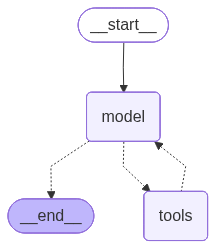

✅ Self-Correction Graph 생성 완료!


In [ ]:
# pre-built
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware
from IPython.display import Image, display

self_correction_agent = create_agent(
    model=llm,
    tools=[create_research_plan]
)
display(Image(self_correction_agent.get_graph().draw_mermaid_png()))
print("✅ Self-Correction Graph 생성 완료!")

In [ ]:
# Error Handling 추가
self_correction_agent = create_agent(
    model=llm,
    tools=[create_research_plan],
    middleware=[
        ToolCallLimitMiddleware(
            tool_name="create_research_plan",
            thread_limit=3, # 현재 대화에서 최대 3번 호출
        )
    ],
)

In [ ]:
query = "AI 관련 리서치 계획 세워줘. 첫 번째 작업 이름은 간단하게 'AI 조사'라고 해줘."

rprint(f"[bold blue]📝 사용자 질문:[/bold blue] {query}")
rprint("=" * 60)

# 에이전트 실행 및 결과 모니터링
for step in self_correction_agent.stream({"messages": [{"role": "user", "content": query}]}):
    for node_name, update in step.items():
        rprint(f"\n[bold green]📍 Node:[/bold green] [yellow]{node_name}[/yellow]")

        if update is None:
            continue

        for message in update.get("messages", []):
            # 1. AI의 생각 (Tool Calling 포함)
            if hasattr(message, "tool_calls") and message.tool_calls:
                rprint("[bold cyan]🤖 AI의 도구 호출 시도:[/bold cyan]")
                rprint(message.tool_calls)

            # 2. 도구 실행 결과 (성공 또는 에러)
            elif message.type == "tool":
                # 에러 메시지가 포함되어 있는지 확인하여 색상 구분
                if "too short" in message.content.lower() or "error" in message.content.lower():
                    rprint("[bold red]❌ 도구 실행 결과 (Pydantic 에러 발생):[/bold red]")
                    # rprint(message.content)
                    rprint(message)
                else:
                    rprint("[bold blue]✅ 도구 실행 결과 (성공):[/bold blue]")
                    # rprint(message.content)
                    rprint(message)

            # 3. 최종 자연어 응답
            else:
                rprint("[bold magenta]💬 최종 응답:[/bold magenta]")
                rprint(message.content)

rprint("\n" + "=" * 60)
rprint("[bold green]✅ Self-Correction 루프 종료![/bold green]")

📝 사용자 질문: AI 관련 리서치 계획 세워줘. 첫 번째 작업 이름은 간단하게 'AI 조사'라고 해줘.

============================================================

📍 Node: model

🤖 AI의 도구 호출 시도:

[
    {
        'name': 'create_research_plan',
        'args': {
            'project_title': 'AI 관련 리서치',
            'steps': [
                {
                    'task_name': 'AI 조사',
                    'detailed_objective': '인공지능(AI) 분야의 최신 동향, 핵심 기술, 주요 응용 분야, 산업별 영향 및
미래 전망을 종합적으로 조사하기 위해 신뢰할 수 있는 출처(학술 논문, 산업 보고서, 전문가 인터뷰)에서 데이터를 
수집하고 체계적으로 분류하기',
                    'method': 'PAPER_REVIEW'
                }
            ]
        },
        'id': 'chatcmpl-tool-c12fb30452c74af8934c0c946a449dbb',
        'type': 'tool_call'
    }
]

...

💬 최종 응답:

AI 관련 리서치 계획을 다음과 같이 제안드립니다:

1. **AI 조사**  
   - **목적**: 인공지능 분야의 최신 동향, 핵심 기술, 주요 응용 분야, 산업별 영향 및 미래 전망을 체계적으로 분석하기
   - **방법**: 학술 논문, 산업 보고서, 전문가 인터뷰 등 신뢰할 수 있는 출처에서 데이터 수집 및 연구  
   - **우선순위**: 3 (중간)  

추가 단계가 필요한 경우 구체적인 요구사항(예: 특정 기술 조사, 시장 분석 등)을 알려주시면 확장 계획을 수립해 
드리겠습니다.  

(참고: 시스템 제약으로 인해 도구 호출이 제한되었습니다.)

📍 Node: ToolCallLimitMiddleware.after_model

============================================================

✅ Self-Correction 루프 종료!

**참고 자료**
- https://wandb.ai/jxnlco/function-calls/reports/Better-Data-Extraction-Using-Pydantic-and-OpenAI-Function-Calls--Vmlldzo0ODU4OTA3
- https://docs.pydantic.dev/latest/api/base_model/#pydantic.BaseModel.model_json_schema
- https://www.youtube.com/watch?v=6gYlaJJ8t0w